polars计算自定义因子 yellow_taxi_custom_factor

采样后数据量: 1,813,737 行, 16 列
采样数据字段:
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'total_amount', 'trip_duration_minutes', 'pickup_year']

=== 因子数据概览 ===
shape: (5, 34)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
│ Ven ┆ tpe ┆ tpe ┆ pas ┆ tri ┆ PUL ┆ DOL ┆ pay ┆ far ┆ ext ┆ mta ┆ tip ┆ tol ┆ tot ┆ tri ┆ pic ┆ hou ┆ day ┆ mon ┆ is_ ┆ is_ ┆ is_ ┆ is_ ┆ is_ ┆ far ┆ rev ┆ tip ┆ dis ┆ far ┆ pu_ ┆ pu_ ┆ is_ ┆ glo ┆ hou │
│ dor ┆ p_p ┆ p_d ┆ sen ┆ p_d ┆ oca ┆ oca ┆ men ┆ e_a ┆ ra  ┆ _ta ┆ _am ┆ ls_ ┆ al_ ┆ p_d ┆ kup ┆ r_o ┆ _of ┆ th  ┆ wee ┆ mor ┆ eve ┆ nig ┆ pea ┆ e_p ┆ enu ┆ _ra ┆ tan ┆ e_c ┆ tot ┆ avg ┆ hot ┆ bal ┆ rly │
│ ID  ┆ ick ┆ rop ┆ ger ┆ ist ┆ tio ┆ tio ┆ t_t ┆ 

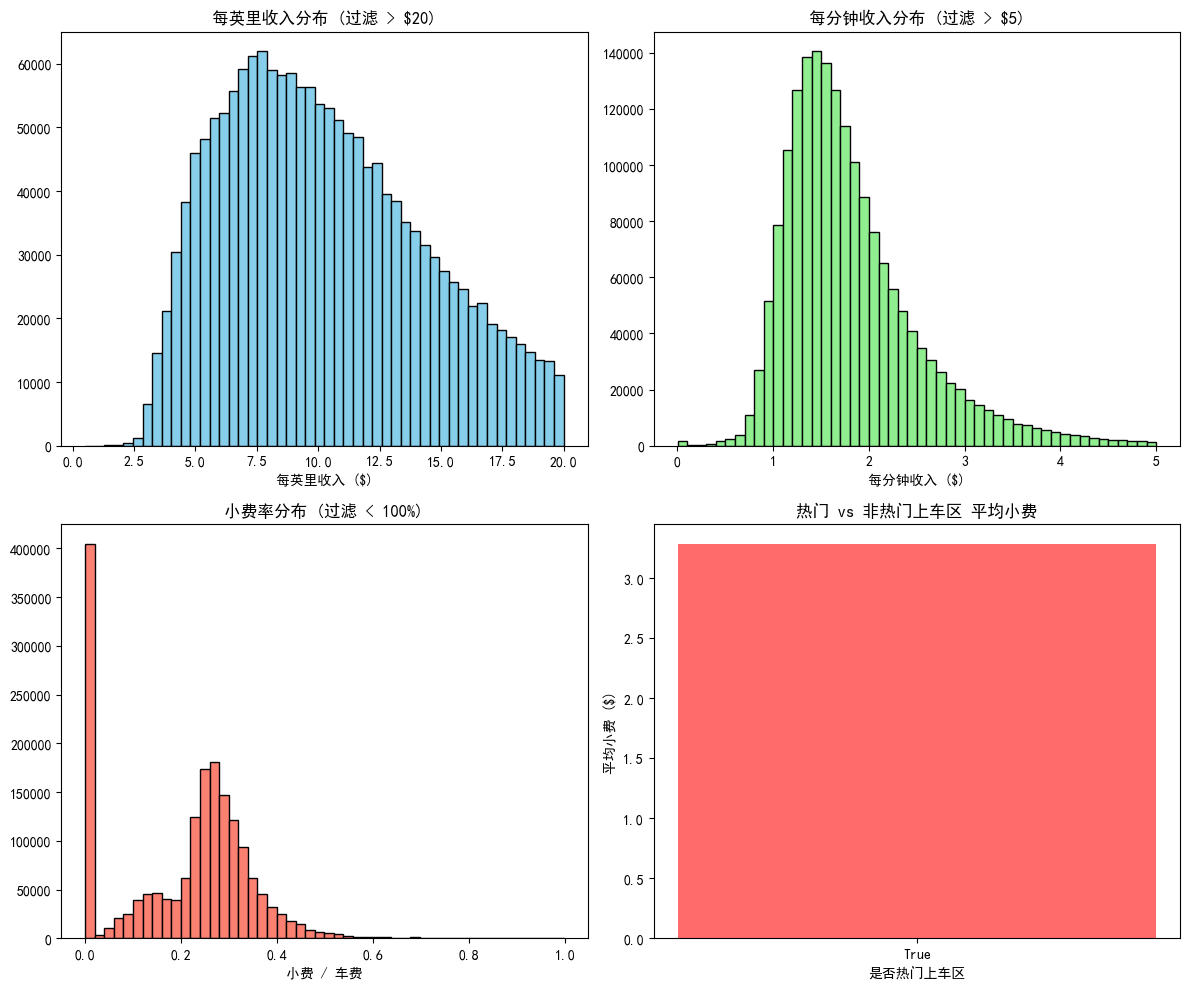

19040

In [7]:
import duckdb
import polars as pl
import os
import matplotlib.pyplot as plt
import gc

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

conn = duckdb.connect()
# 设置 Polars 显示选项
pl.Config.set_tbl_rows(20)  # 显示前20行
pl.Config.set_tbl_cols(-1)  # 显示所有列

# 1. 用DuckDB从Parquet文件中采样数据，转为Polars DataFrame
data_dir = "D:/yellow_taxi/yellow_taxi_data_cleaned/"
# 随机采样1%
sampled_df = conn.execute(f"""
SELECT * FROM read_parquet('{data_dir}/**/*.parquet')
USING SAMPLE 1 PERCENT
""").pl()

print(f"采样后数据量: {sampled_df.height:,} 行, {sampled_df.width} 列")
print("采样数据字段:")
print(sampled_df.columns)
conn.close()

# 2. 基础因子计算 (用Polars表达式)
# 添加时间特征
df_with_factors = sampled_df.with_columns([
    # 提取小时
    pl.col("tpep_pickup_datetime").dt.hour().alias("hour_of_day"),
    # 提取星期几（0=周一, 6=周日）
    pl.col("tpep_pickup_datetime").dt.weekday().alias("day_of_week"),
    # 提取月份
    pl.col("tpep_pickup_datetime").dt.month().alias("month"),
])

# 添加布尔标志因子
df_with_factors = df_with_factors.with_columns([
    # 是否周末（周六=6, 周日=7）
    (pl.col("day_of_week").is_in([6, 7])).alias("is_weekend"),
    # 是否早高峰（7-9点）
    (pl.col("hour_of_day").is_between(7, 9)).alias("is_morning_peak"),
    # 是否晚高峰（17-19点）
    (pl.col("hour_of_day").is_between(17, 19)).alias("is_evening_peak"),
    # 是否夜间（22-5点）
    (pl.col("hour_of_day") >= 22).or_(pl.col("hour_of_day") <= 5).alias("is_night"),
])
# 添加是否高峰（早或晚）,依赖上面的两列
df_with_factors = df_with_factors.with_columns([
    (pl.col("is_morning_peak") | pl.col("is_evening_peak")).alias("is_peak_hour")
])
    
# 添加比率因子
df_with_factors = df_with_factors.with_columns([
    # 每英里收入（避免除零）
    (pl.col("total_amount") / pl.col("trip_distance")).alias("fare_per_mile"),
    # 每分钟收入
    (pl.col("total_amount") / pl.col("trip_duration_minutes")).alias("revenue_per_minute"),
    # 小费占车费比例（避免除零，且只处理 tip_amount > 0 的情况）
    (pl.col("tip_amount") / pl.col("fare_amount").replace(0, float('nan'))).alias("tip_rate"),
])

# 添加分类因子
df_with_factors = df_with_factors.with_columns([
    # 距离分类
    pl.col("trip_distance").cut(
        breaks=[2, 10],
        labels=["short", "medium", "long"]
    ).alias("distance_category"),
    # 车费分类（按分位数）
    pl.col("fare_amount").cut(
        breaks=[10, 20, 50],
        labels=["very_low", "low", "medium", "high"]
    ).alias("fare_category"),
])

# 3. 高级因子（需要分组窗口，展示 Polars 的优势）
# 高级因子1：按区域统计需求热度（作为特征回填）
# 计算每个 PULocationID 的总订单量，然后关联回原表
popularity_by_pu = df_with_factors.group_by("PULocationID").agg([
    pl.len().alias("pu_total_trips"),
    pl.col("total_amount").mean().alias("pu_avg_total"),
])

df_with_factors = df_with_factors.join(
    popularity_by_pu,
    on="PULocationID",
    how="left"
)

# 高级因子2：是否热门区域（订单量前 10%）
total_trips = df_with_factors.height
top_10_percent_threshold = int(total_trips * 0.1)
top_10_pu = (df_with_factors.group_by("PULocationID").agg(pl.len()).sort("len", descending=True)
             .head(top_10_percent_threshold).get_column("PULocationID")).to_list()
df_with_factors = df_with_factors.with_columns(
    pl.col("PULocationID").is_in(top_10_pu).alias("is_hot_pu")
)

# 高级因子3：滚动统计
# 按小时统计全局订单量，作为时间特征
hourly_popularity = df_with_factors.group_by("hour_of_day").agg([
    pl.len().alias("global_trips_by_hour")
])
df_with_factors = df_with_factors.join(hourly_popularity, on="hour_of_day", how="left")
df_with_factors = df_with_factors.with_columns(
    (pl.col("global_trips_by_hour") / total_trips).alias("hourly_demand_share")
)

# 4. 数据清洗（在 Polars 中做最后过滤）
# 过滤掉除以零产生的 NaN 或无穷值
df_final = df_with_factors.filter(
    (pl.col("fare_per_mile").is_finite()) &
    (pl.col("revenue_per_minute").is_finite()) &
    (pl.col("tip_rate").is_finite().fill_null(True))  # 允许 tip_rate 为空
)

print("\n=== 因子数据概览 ===")
print(df_final.head())

print("\n=== 数据类型检查 ===")
print(df_final.schema)

# 5. 导出因子数据，供阶段六回归建模使用
# 选择回归建模需要的列
regression_columns = [
    "tip_amount",           # 因变量
    "trip_distance",        # 特征
    "passenger_count",      # 特征
    "fare_amount",          # 特征
    "trip_duration_minutes",# 特征
    "hour_of_day",          # 特征
    "is_weekend",           # 特征
    "is_peak_hour",         # 特征
    "is_night",             # 特征
    "fare_per_mile",        # 特征
    "revenue_per_minute",   # 特征
    "tip_rate",             # 特征
    "distance_category",    # 特征（类别）
    "is_hot_pu",            # 特征（是否热门上车区）
    "PULocationID",         # 区域ID
    "payment_type",         # 支付方式
]

# 只保留存在的列
existing_columns = [col for col in regression_columns if col in df_final.columns]
df_regression = df_final.select(existing_columns)

# 处理分类变量：将字符串类别转为数值编码
df_regression = df_regression.with_columns([
    pl.col("distance_category").cast(pl.Categorical).to_physical().alias("distance_code"),
    pl.col("payment_type").cast(pl.Utf8).cast(pl.Categorical).to_physical().alias("payment_code")
])

# 删除原字符串列
df_regression = df_regression.drop(["distance_category"])

# 去掉缺少因变量的行
df_regression = df_regression.filter(pl.col("tip_amount").is_not_null())

# 保存为 CSV 和 Parquet
os.makedirs("D:/yellow_taxi/yellow_taxi_custom_factor", exist_ok=True)
df_regression.write_parquet("D:/yellow_taxi/yellow_taxi_custom_factor/regression_data.parquet")
df_regression.write_csv("D:/yellow_taxi/yellow_taxi_custom_factor/regression_data.csv")

print(f"\n回归数据集已保存，共 {df_regression.height:,} 行，{df_regression.width} 列")
print("列名:", df_regression.columns)

# 6. 因子分布快速可视化（确认数据质量）
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 每英里收入分布（限制 x 轴范围去除极端值）
fare_per_mile = df_regression.filter(pl.col("fare_per_mile") < 20)["fare_per_mile"].to_numpy()
axes[0, 0].hist(fare_per_mile, bins=50, color='skyblue', edgecolor='black')
axes[0, 0].set_title('每英里收入分布 (过滤 > $20)')
axes[0, 0].set_xlabel('每英里收入 ($)')

# 每分钟收入分布
rpm = df_regression.filter(pl.col("revenue_per_minute") < 5)["revenue_per_minute"].to_numpy()
axes[0, 1].hist(rpm, bins=50, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('每分钟收入分布 (过滤 > $5)')
axes[0, 1].set_xlabel('每分钟收入 ($)')

# 小费率分布
tip_rate = df_regression.filter(pl.col("tip_rate") < 1)["tip_rate"].to_numpy()
axes[1, 0].hist(tip_rate, bins=50, color='salmon', edgecolor='black')
axes[1, 0].set_title('小费率分布 (过滤 < 100%)')
axes[1, 0].set_xlabel('小费 / 车费')

# 是否热门上车区的平均小费对比
is_hot = df_regression.group_by("is_hot_pu").agg(pl.col("tip_amount").mean()).to_pandas()
axes[1, 1].bar(is_hot["is_hot_pu"].astype(str), is_hot["tip_amount"], color=['#FF6B6B', '#4ECDC4'])
axes[1, 1].set_title('热门 vs 非热门上车区 平均小费')
axes[1, 1].set_xlabel('是否热门上车区')
axes[1, 1].set_ylabel('平均小费 ($)')

plt.tight_layout()
plt.savefig('D:/yellow_taxi/yellow_taxi_custom_factor/factor_distributions.png', dpi=150)
plt.show()

# 删除大对象
lazy_df = None
sampled_df = None
df_with_factors = None
popularity_by_pu = None
hourly_popularity = None
top_10_pu = None
df_regression = None
gc.collect()